# Laptop Price Prediction Using Machine Learning

**Project:** Laptop Price Prediction    
**Task:** Predict laptop prices from hardware and specification features using machine learning.

This notebook covers data cleaning, feature engineering, exploratory data analysis, preprocessing, model training, evaluation, feature importance, and price prediction.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. Load Dataset

In [2]:
df = pd.read_csv("laptop_price.csv")
df.head()

,Unnamed: 0.1,Unnamed: 0,brand,name,price,spec_rating,processor,CPU,Ram,Ram_type,ROM,ROM_type,GPU,display_size,resolution_width,resolution_height,OS,warranty
0,0,0,HP,Victus 15-fb0157AX Gaming Laptop,49900,73.000000,5th Gen AMD Ryzen 5 5600H,"Hexa Core, 12 Threads",8GB,DDR4,512GB,SSD,4GB AMD Radeon RX 6500M,15.6,1920.0,1080.0,Windows 11 OS,1
1,1,1,HP,15s-fq5007TU Laptop,39900,60.000000,12th Gen Intel Core i3 1215U,"Hexa Core (2P + 4E), 8 Threads",8GB,DDR4,512GB,SSD,Intel UHD Graphics,15.6,1920.0,1080.0,Windows 11 OS,1
2,2,2,Acer,One 14 Z8-415 Laptop,26990,69.323529,11th Gen Intel Core i3 1115G4,"Dual Core, 4 Threads",8GB,DDR4,512GB,SSD,Intel Iris Xe Graphics,14.0,1920.0,1080.0,Windows 11 OS,1
3,3,3,Lenovo,Yoga Slim 6 14IAP8 82WU0095IN Laptop,59729,66.000000,12th Gen Intel Core i5 1240P,"12 Cores (4P + 8E), 16 Threads",16GB,LPDDR5,512GB,SSD,Intel Integrated Iris Xe,14.0,2240.0,1400.0,Windows 11 OS,1
4,4,4,Apple,MacBook Air 2020 MGND3HN Laptop,69990,69.323529,Apple M1,Octa Core (4P + 4E),8GB,DDR4,256GB,SSD,Apple M1 Integrated Graphics,13.3,2560.0,1600.0,Mac OS,1


## 3. Initial Dataset Inspection

In [3]:
df.shape

(893, 18)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 893 entries, 0 to 892
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0.1       893 non-null    int64  
 1   Unnamed: 0         893 non-null    int64  
 2   brand              893 non-null    object 
 3   name               893 non-null    object 
 4   price              893 non-null    int64  
 5   spec_rating        893 non-null    float64
 6   processor          893 non-null    object 
 7   CPU                893 non-null    object 
 8   Ram                893 non-null    object 
 9   Ram_type           893 non-null    object 
 10  ROM                893 non-null    object 
 11  ROM_type           893 non-null    object 
 12  GPU                893 non-null    object 
 13  display_size       893 non-null    float64
 14  resolution_width   893 non-null    float64
 15  resolution_height  893 non-null    float64
 16  OS                 893 non

In [5]:
df.isnull().sum()

Unnamed: 0.1         0
Unnamed: 0           0
brand                0
name                 0
price                0
spec_rating          0
processor            0
CPU                  0
Ram                  0
Ram_type             0
ROM                  0
ROM_type             0
GPU                  0
display_size         0
resolution_width     0
resolution_height    0
OS                   0
warranty             0
dtype: int64

In [6]:
df.describe()

,Unnamed: 0.1,Unnamed: 0,price,spec_rating,display_size,resolution_width,resolution_height,warranty
count,893.000000,893.000000,893.000000,893.000000,893.000000,893.000000,893.000000,893.000000
mean,467.135498,521.382979,79907.409854,69.379026,15.173751,2035.393057,1218.324748,1.079507
std,270.209769,299.916605,60880.043823,5.541555,0.939095,426.076009,326.756883,0.326956
min,0.000000,0.000000,9999.000000,60.000000,11.600000,1080.000000,768.000000,0.000000
25%,235.000000,265.000000,44500.000000,66.000000,14.000000,1920.000000,1080.000000,1.000000
50%,467.000000,531.000000,61990.000000,69.323529,15.600000,1920.000000,1080.000000,1.000000
75%,702.000000,784.000000,90990.000000,71.000000,15.600000,1920.000000,1200.000000,1.000000
max,930.000000,1019.000000,450039.000000,89.000000,18.000000,3840.000000,3456.000000,3.000000


## 4. Data Cleaning

### Remove Unnecessary Index Columns

In [7]:
df = df.drop(['Unnamed: 0.1', 'Unnamed: 0'], axis=1)

### Clean RAM and Storage Values

In [8]:
df['Ram'] = df['Ram'].str.replace('GB', '', regex=False).astype(int)

In [9]:
df['ROM'] = df['ROM'].str.replace('GB', '', regex=False)

In [10]:
df['ROM'] = df['ROM'].replace({
    '1TB': '1024',
    '2TB': '2048'
}).astype(int)

In [11]:
df[['Ram', 'ROM']].dtypes

Ram    int64
ROM    int64
dtype: object

### Clean Operating System and RAM Type

In [12]:
df['OS'] = df['OS'].str.replace(r'\s+', ' ', regex=True).str.strip()

In [13]:
df['OS'] = df['OS'].replace({
    'Windows 10 OS': 'Windows 10',
    'Windows 10  OS': 'Windows 10',
    'Windows 11 OS': 'Windows 11',
    'Windows 11  OS': 'Windows 11',
    'Windows OS': 'Windows'
})

In [14]:
df['OS'] = df['OS'].str.replace(' OS', '', regex=False)

In [15]:
df['Ram_type'] = df['Ram_type'].str.upper().str.replace('-', '', regex=False)

## 5. Feature Engineering

### Processor Features

In [16]:
df['processor_generation'] = df['processor'].str.extract(r'(\d+)(?:th|st|nd|rd)\s+Gen')[0]

In [17]:
df['processor_generation'] = pd.to_numeric(
    df['processor_generation'],
    errors='coerce'
)

In [18]:
def get_processor_brand(processor):
    processor = processor.lower()
    
    if 'intel' in processor:
        return 'Intel'
    elif 'amd' in processor:
        return 'AMD'
    elif 'apple' in processor:
        return 'Apple'
    elif 'mediatek' in processor:
        return 'MediaTek'
    else:
        return 'Other'

df['processor_brand'] = df['processor'].apply(get_processor_brand)

In [19]:
def get_processor_family(processor):
    processor = processor.lower()
    
    if 'core i9' in processor:
        return 'Core i9'
    elif 'core i7' in processor:
        return 'Core i7'
    elif 'core i5' in processor:
        return 'Core i5'
    elif 'core i3' in processor:
        return 'Core i3'
    elif 'ryzen 9' in processor:
        return 'Ryzen 9'
    elif 'ryzen 7' in processor:
        return 'Ryzen 7'
    elif 'ryzen 5' in processor:
        return 'Ryzen 5'
    elif 'ryzen 3' in processor:
        return 'Ryzen 3'
    elif 'celeron' in processor:
        return 'Celeron'
    elif 'athlon' in processor:
        return 'Athlon'
    elif 'apple' in processor:
        return 'Apple'
    elif 'mediatek' in processor:
        return 'MediaTek'
    else:
        return 'Other'

df['processor_family'] = df['processor'].apply(get_processor_family)

### CPU Features

In [20]:
df['CPU_cores'] = df['CPU'].str.extract(r'(\d+)\s+Cores?')[0]
df['CPU_cores'] = pd.to_numeric(df['CPU_cores'], errors='coerce')

In [21]:
df['CPU_threads'] = df['CPU'].str.extract(r'(\d+)\s+Threads?')[0]
df['CPU_threads'] = pd.to_numeric(df['CPU_threads'], errors='coerce')

In [22]:
def get_cpu_cores(cpu):
    cpu = cpu.lower()
    
    if 'dual core' in cpu:
        return 2
    elif 'quad core' in cpu:
        return 4
    elif 'hexa core' in cpu:
        return 6
    elif 'octa core' in cpu:
        return 8
    else:
        return None

df['CPU_cores'] = df['CPU_cores'].fillna(
    df['CPU'].apply(get_cpu_cores)
)

### GPU Features

In [23]:
def get_gpu_brand(gpu):
    gpu = gpu.lower()
    
    if 'nvidia' in gpu:
        return 'NVIDIA'
    elif 'amd' in gpu or 'radeon' in gpu:
        return 'AMD'
    elif 'intel' in gpu:
        return 'Intel'
    elif 'apple' in gpu:
        return 'Apple'
    elif 'arm' in gpu:
        return 'ARM'
    else:
        return 'Other'

df['GPU_brand'] = df['GPU'].apply(get_gpu_brand)

In [24]:
df['GPU_memory'] = df['GPU'].str.extract(r'(\d+)GB')[0]
df['GPU_memory'] = pd.to_numeric(df['GPU_memory'], errors='coerce')

In [25]:
def get_gpu_type(gpu):
    gpu = gpu.lower()
    
    if 'nvidia' in gpu or 'radeon rx' in gpu or 'radeon rtx' in gpu:
        return 'Dedicated'
    else:
        return 'Integrated'

df['GPU_type'] = df['GPU'].apply(get_gpu_type)

### Display Resolution Feature

In [26]:
df['total_pixels'] = df['resolution_width'] * df['resolution_height']

### Check Missing Values After Feature Engineering

In [27]:
df.isnull().sum()

brand                     0
name                      0
price                     0
spec_rating               0
processor                 0
CPU                       0
Ram                       0
Ram_type                  0
ROM                       0
ROM_type                  0
GPU                       0
display_size              0
resolution_width          0
resolution_height         0
OS                        0
warranty                  0
processor_generation     55
processor_brand           0
processor_family          0
CPU_cores                 1
CPU_threads              26
GPU_brand                 0
GPU_memory              576
GPU_type                  0
total_pixels              0
dtype: int64

The remaining missing values are handled later inside the preprocessing pipeline. Missing GPU memory is not automatically converted to zero because an unspecified value does not necessarily mean zero dedicated memory.

## 6. Exploratory Data Analysis

### Price Distribution

In [28]:
df['price'].describe()

count       893.000000
mean      79907.409854
std       60880.043823
min        9999.000000
25%       44500.000000
50%       61990.000000
75%       90990.000000
max      450039.000000
Name: price, dtype: float64

<Axes: ylabel='Frequency'>

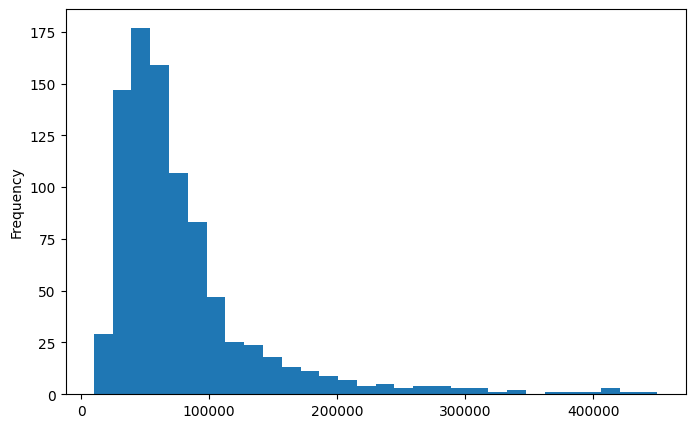

In [29]:
df['price'].plot(kind='hist', bins=30, figsize=(8,5))

In [30]:
df['price'].skew()

np.float64(2.709694252311729)

The price distribution is strongly right-skewed, indicating that a smaller number of high-priced laptops pull the distribution upward.

### Average Price by Major Features

#### Brand

In [31]:
df.groupby('brand')['price'].mean().sort_values(ascending=False)

brand
Razer        199990.000000
Apple        174230.875000
Gigabyte     133279.125000
LG           128618.444444
Samsung      117512.142857
MSI          100849.630769
Dell          91150.934579
Fujitsu       81656.666667
HP            80872.473118
Ninkear       79999.000000
Asus          75774.191083
Lenovo        70060.946746
Microsoft     60440.000000
Acer          58651.178571
Huawei        56999.000000
Xiaomi        56543.875000
Honor         47490.000000
Realme        44329.333333
Tecno         43999.000000
Infinix       43990.000000
Vaio          39990.000000
Zebronics     37990.000000
Wings         37323.333333
Chuwi         31659.666667
Avita         21990.000000
Ultimus       19115.000000
Walker        16990.000000
AXL           14490.000000
Primebook     10990.000000
iBall          9999.000000
Name: price, dtype: float64

#### Processor Brand

In [32]:
df.groupby('processor_brand')['price'].mean().sort_values(ascending=False)

processor_brand
Apple       183608.166667
Intel        83888.541463
AMD          66232.362264
MediaTek     10990.000000
Name: price, dtype: float64

#### RAM

In [33]:
df.groupby('Ram')['price'].mean().sort_index()

Ram
2       9999.000000
4      19780.409091
8      49270.355014
12     42990.000000
16     91741.901316
32    238026.800000
64    430009.666667
Name: price, dtype: float64

#### Storage

In [34]:
df.groupby('ROM')['price'].mean().sort_index()

ROM
32       10494.500000
64       20576.000000
128      26585.916667
256      41868.190476
512      64057.029968
1024    136777.978723
2048    282953.600000
Name: price, dtype: float64

#### Processor Family

In [35]:
df.groupby('processor_family')['price'].mean().sort_values(ascending=False)

processor_family
Core i9     239848.055556
Ryzen 9     228023.875000
Apple       183608.166667
Core i7     123426.702703
Ryzen 7      87959.068966
Other        71269.285714
Core i5      67674.560976
Ryzen 5      52862.218750
Core i3      38301.706422
Ryzen 3      32755.941176
Athlon       24360.000000
Celeron      21192.892857
MediaTek     10990.000000
Name: price, dtype: float64

#### GPU Brand

In [36]:
df.groupby('GPU_brand')['price'].mean().sort_values(ascending=False)

GPU_brand
Other     173289.384615
NVIDIA    115240.193443
Apple      91490.000000
Intel      62604.781407
AMD        50836.913793
ARM        10990.000000
Name: price, dtype: float64

#### GPU Type

In [37]:
df.groupby('GPU_type')['price'].mean().sort_values(ascending=False)

GPU_type
Dedicated     113055.132075
Integrated     61575.278261
Name: price, dtype: float64

These group-wise averages are descriptive. They show patterns in this dataset but do not establish causal relationships.

### Numerical Correlation with Price

In [38]:
df[['price', 'spec_rating', 'Ram', 'ROM', 'display_size',
    'resolution_width', 'resolution_height', 'total_pixels',
    'CPU_cores', 'CPU_threads', 'GPU_memory',
    'processor_generation']].corr()['price'].sort_values(ascending=False)

price                   1.000000
GPU_memory              0.816986
CPU_threads             0.738380
Ram                     0.736924
CPU_cores               0.712026
total_pixels            0.628488
ROM                     0.624741
resolution_height       0.604748
resolution_width        0.586042
spec_rating             0.546391
processor_generation    0.268579
display_size            0.233815
Name: price, dtype: float64

Correlation is used here to identify numerical relationships with price. Correlation does not imply causation.

## 7. Feature Selection

The final feature set uses engineered and relatively useful variables while removing high-cardinality/raw fields such as `name`, `processor`, `CPU`, and `GPU`. The two individual resolution dimensions are represented through `total_pixels` to reduce redundancy.

In [39]:
features = [
    'brand',
    'spec_rating',
    'Ram',
    'Ram_type',
    'ROM',
    'ROM_type',
    'display_size',
    'OS',
    'warranty',
    'processor_generation',
    'processor_brand',
    'processor_family',
    'CPU_cores',
    'CPU_threads',
    'GPU_brand',
    'GPU_memory',
    'GPU_type',
    'total_pixels'
]

X = df[features]
y = df['price']

In [40]:
X.shape, y.shape

((893, 18), (893,))

In [41]:
X.dtypes

brand                    object
spec_rating             float64
Ram                       int64
Ram_type                 object
ROM                       int64
ROM_type                 object
display_size            float64
OS                       object
warranty                  int64
processor_generation    float64
processor_brand          object
processor_family         object
CPU_cores               float64
CPU_threads             float64
GPU_brand                object
GPU_memory              float64
GPU_type                 object
total_pixels            float64
dtype: object

## 8. Train-Test Split

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [43]:
X_train.shape, X_test.shape

((714, 18), (179, 18))

## 9. Data Preprocessing

Numerical features use median imputation for missing values. Categorical features use most-frequent imputation followed by one-hot encoding. `handle_unknown='ignore'` allows the model to handle unseen categories during prediction.

In [44]:
numerical_features = [
    'spec_rating',
    'Ram',
    'ROM',
    'display_size',
    'warranty',
    'processor_generation',
    'CPU_cores',
    'CPU_threads',
    'GPU_memory',
    'total_pixels'
]

categorical_features = [
    'brand',
    'Ram_type',
    'ROM_type',
    'OS',
    'processor_brand',
    'processor_family',
    'GPU_brand',
    'GPU_type'
]

In [45]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

In [46]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [47]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

## 10. Random Forest Regression

A Random Forest Regressor is trained using 200 trees with a fixed random state for reproducibility.

In [48]:
from sklearn.ensemble import RandomForestRegressor

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

In [49]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [50]:
y_pred = model.predict(X_test)

In [51]:
comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,83090,85719.085000
1,57580,65583.625417
2,58990,61668.467500
3,142990,135981.398750
4,74990,88451.760833
5,56990,74404.439167
6,53990,44369.623333
7,57990,63301.930798
8,72490,82307.105000
9,23990,17539.925000


### Random Forest Evaluation

In [52]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 12646.16181642442
RMSE: 23017.247827289713
R² Score: 0.8453899480796246


**Random Forest results:**  
- MAE ≈ ₹12,646.16  
- RMSE ≈ ₹23,017.25  
- R² ≈ 0.8454

The R² value indicates that the model explains about 84.5% of the variation in the test-set prices. MAE gives the average absolute prediction error in rupees.

## 11. Linear Regression Comparison

In [53]:
from sklearn.linear_model import LinearRegression

linear_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

linear_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [54]:
y_pred_linear = linear_model.predict(X_test)

In [55]:
mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print("MAE:", mae_linear)
print("RMSE:", rmse_linear)
print("R² Score:", r2_linear)

MAE: 19075.835693373516
RMSE: 27823.304502626386
R² Score: 0.7740832894275302


### Model Comparison

In [56]:
comparison_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae_linear, mae],
    'RMSE': [rmse_linear, rmse],
    'R2 Score': [r2_linear, r2]
})

comparison_results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,19075.835693,27823.304503,0.774083
1,Random Forest,12646.161816,23017.247827,0.845390


Random Forest has lower MAE and RMSE and a higher R² score than Linear Regression on the same test set. Therefore, Random Forest provides the stronger predictive performance for this dataset under the current preprocessing and split.

## 12. Feature Importance

In [57]:
feature_names = model.named_steps['preprocessor'].get_feature_names_out()

importances = model.named_steps['model'].feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
9,num__total_pixels,0.199795
1,num__Ram,0.188232
8,num__GPU_memory,0.140485
0,num__spec_rating,0.135492
6,num__CPU_cores,0.115881
3,num__display_size,0.034850
7,num__CPU_threads,0.032379
2,num__ROM,0.026409
69,cat__processor_family_Core i7,0.018183
5,num__processor_generation,0.010865


The Random Forest feature importance values indicate which transformed features contributed most to the model's predictions. These values describe model behavior and should not be interpreted as proof that a feature causally determines laptop price.

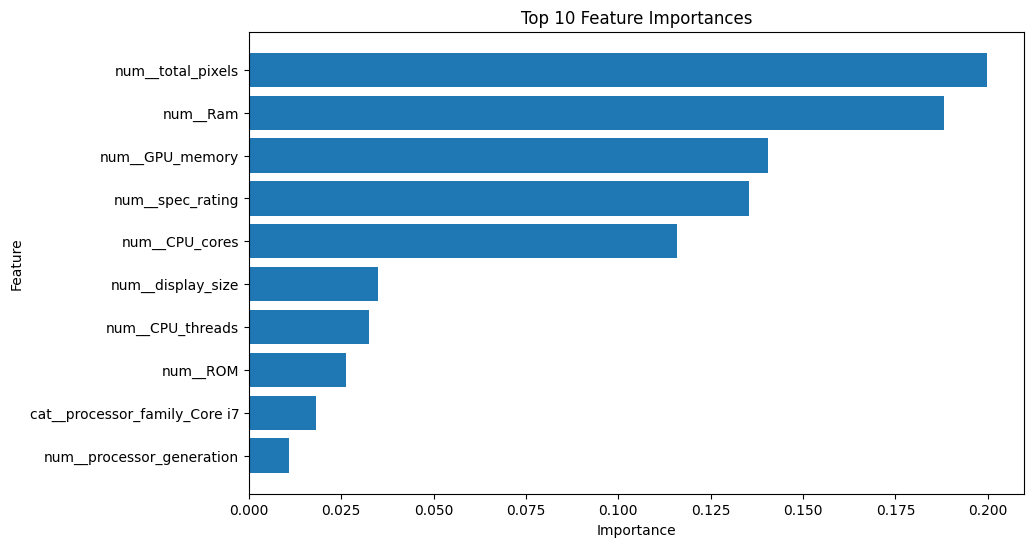

In [58]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances")
plt.gca().invert_yaxis()
plt.show()

## 13. Actual vs Predicted Prices

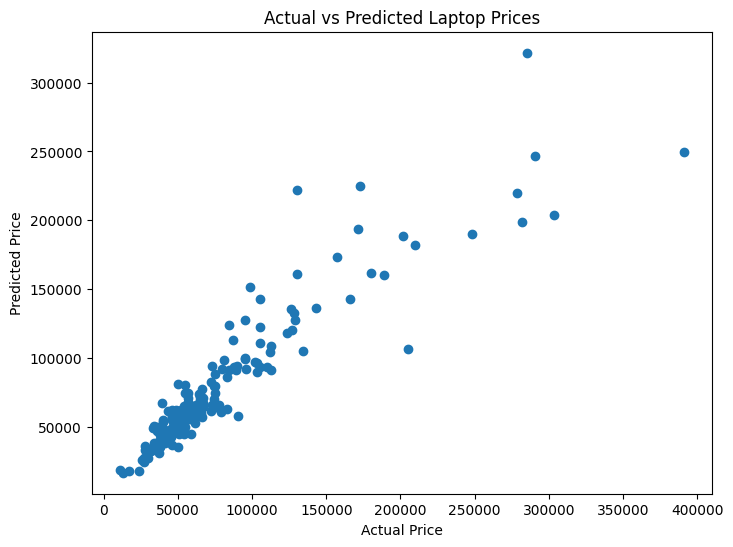

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Laptop Prices")
plt.show()

## 14. Prediction on an Unseen Test Example

In [60]:
sample = X_test.iloc[0:1]

predicted_price = model.predict(sample)[0]
actual_price = y_test.iloc[0]

print("Actual Price: ₹", round(actual_price, 2))
print("Predicted Price: ₹", round(predicted_price, 2))

Actual Price: ₹ 83090
Predicted Price: ₹ 85719.08


## 15. Prediction for a New Laptop

In [61]:
new_laptop = pd.DataFrame([{
    'brand': 'HP',
    'spec_rating': 70,
    'Ram': 16,
    'Ram_type': 'DDR4',
    'ROM': 512,
    'ROM_type': 'SSD',
    'display_size': 15.6,
    'OS': 'Windows 11',
    'warranty': 1,
    'processor_generation': 13,
    'processor_brand': 'Intel',
    'processor_family': 'Core i5',
    'CPU_cores': 10,
    'CPU_threads': 12,
    'GPU_brand': 'Intel',
    'GPU_memory': np.nan,
    'GPU_type': 'Integrated',
    'total_pixels': 1920 * 1080
}])

In [62]:
predicted_price = model.predict(new_laptop)[0]

print("Predicted Laptop Price: ₹", round(predicted_price, 2))

Predicted Laptop Price: ₹ 75641.77


## 16. Interactive Laptop Price Prediction

The following function accepts laptop specifications from the user and returns a predicted price using the trained Random Forest pipeline.

In [63]:
def predict_laptop_price():
    brand = input("Brand: ")
    spec_rating = float(input("Spec Rating: "))
    ram = int(input("RAM (GB): "))
    ram_type = input("RAM Type: ")
    rom = int(input("Storage (GB): "))
    rom_type = input("Storage Type: ")
    display_size = float(input("Display Size (inches): "))
    os = input("Operating System: ")
    warranty = int(input("Warranty (years): "))
    processor_generation = float(input("Processor Generation: "))
    processor_brand = input("Processor Brand: ")
    processor_family = input("Processor Family: ")
    cpu_cores = float(input("CPU Cores: "))
    cpu_threads = float(input("CPU Threads: "))
    gpu_brand = input("GPU Brand: ")
    gpu_memory = input("GPU Memory (GB, press Enter if none): ")
    gpu_type = input("GPU Type: ")
    total_pixels = float(input("Total Pixels: "))

    if gpu_memory == "":
        gpu_memory = np.nan
    else:
        gpu_memory = float(gpu_memory)

    new_laptop = pd.DataFrame([{
        'brand': brand,
        'spec_rating': spec_rating,
        'Ram': ram,
        'Ram_type': ram_type,
        'ROM': rom,
        'ROM_type': rom_type,
        'display_size': display_size,
        'OS': os,
        'warranty': warranty,
        'processor_generation': processor_generation,
        'processor_brand': processor_brand,
        'processor_family': processor_family,
        'CPU_cores': cpu_cores,
        'CPU_threads': cpu_threads,
        'GPU_brand': gpu_brand,
        'GPU_memory': gpu_memory,
        'GPU_type': gpu_type,
        'total_pixels': total_pixels
    }])

    predicted_price = model.predict(new_laptop)[0]

    print("Predicted Laptop Price: ₹", round(predicted_price, 2))

In [64]:
predict_laptop_price()

Brand:  HP
Spec Rating:  70
RAM (GB):  16
RAM Type:  DDR4
Storage (GB):  512
Storage Type:  SSD
Display Size (inches):  15.6
Operating System:  Windows 11
Warranty (years):  1
Processor Generation:  13
Processor Brand:  Intel
Processor Family:  Core i5
CPU Cores:  10
CPU Threads:  12
GPU Brand:  Intel
GPU Memory (GB, press Enter if none):  
GPU Type:  Integrated
Total Pixels:  2073600


Predicted Laptop Price: ₹ 75641.77


## 17. Conclusion

The project demonstrates an end-to-end machine learning workflow for laptop price prediction. Feature engineering converted raw specification text into structured numerical and categorical features. After preprocessing, Linear Regression and Random Forest Regression were compared using MAE, RMSE, and R².

Random Forest achieved the stronger test-set performance in this experiment, with an R² of approximately 0.8454 and an MAE of approximately ₹12,646.

### Future Scope
- Test additional regression models such as Gradient Boosting or XGBoost.
- Perform hyperparameter tuning and cross-validation.
- Add a web interface for easier user interaction.
- Include more recent and diverse laptop listings.
- Investigate model explainability using techniques such as permutation importance or SHAP.